In [1]:
import numpy as np
import copy
import matplotlib.pyplot as plt
%matplotlib inline
import lenstronomy
print("This notebook is running with lenstronomy version", lenstronomy.__version__)

This notebook is running with lenstronomy version 1.13.6


In [2]:
# import the LensModel class #
from lenstronomy.LensModel.lens_model import LensModel

# specify the choice of lens models #
lens_model_list = ['EPL', 'SHEAR']

# setup lens model class with the list of lens models #
lensModel = LensModel(lens_model_list=lens_model_list)

# define parameter values of lens models #
kwargs_spep = {'theta_E': 1.1, 'e1': 0.1, 'e2': 0.1, 'gamma': 2., 'center_x': 0.0, 'center_y': 0}
kwargs_shear = {'gamma1': -0.01, 'gamma2': .03}
kwargs_lens = [kwargs_spep, kwargs_shear]


# image plane coordinate #
theta_ra, theta_dec = 1.3, .0

# source plane coordinate #
beta_ra, beta_dec = lensModel.ray_shooting(theta_ra, theta_dec, kwargs_lens)
# Fermat potential #
fermat_pot = lensModel.fermat_potential(x_image=theta_ra, y_image=theta_dec, x_source=beta_ra, y_source=beta_dec, kwargs_lens=kwargs_lens)

# Magnification #
mag = lensModel.magnification(theta_ra, theta_dec, kwargs_lens)

In [3]:
# keep the imports and variables from above #
# specify redshifts of deflectors #
redshift_list = [0.5, 0.5, 1.]
# specify source redshift #
z_source = 1.5
# setup lens model class with the list of lens models #
lens_model_list_mp = ['EPL', 'SHEAR', 'SIS']
lensModel_mp = LensModel(lens_model_list=lens_model_list_mp, z_source=z_source, lens_redshift_list=redshift_list, multi_plane=True)

kwargs_sis = {'theta_E': 0.3, 'center_x': .0, 'center_y': -0.1}
kwargs_lens_mp = [kwargs_spep, kwargs_shear, kwargs_sis]

# source plane coordinate #
beta_ra, beta_dec = lensModel_mp.ray_shooting(theta_ra, theta_dec, kwargs_lens_mp)

# Magnification #
mag = lensModel_mp.magnification(theta_ra, theta_dec, kwargs_lens_mp)

# arrival time relative to a straight path through (0,0) #
dt = lensModel_mp.arrival_time(theta_ra, theta_dec, kwargs_lens_mp)

/home/julz_t/miniconda3/envs/lenstool/lib/python3.14/site-packages/lenstronomy/LensModel/MultiPlane/multi_plane.py:81: UserWarning: Cosmology is provided. Make sure your cosmological model is consistent with the cosmology_model argument.
  warnings.warn(


In [4]:
# keep the imports and variables from above #
# import the lens equation solver class #
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver

# specifiy the lens model class to deal with #
solver = LensEquationSolver(lensModel)

# solve for image positions provided a lens model and the source position #
theta_ra, theta_dec = solver.image_position_from_source(beta_ra, beta_dec, kwargs_lens)

# the magnification of the point source images #
mag = lensModel.magnification(theta_ra, theta_dec, kwargs_lens)

/home/julz_t/miniconda3/envs/lenstool/lib/python3.14/site-packages/lenstronomy/Plots/lens_plot.py:180: RuntimeWarning: invalid value encountered in log10
  np.log10(kappa_result),
/tmp/ipykernel_1345/3807885781.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


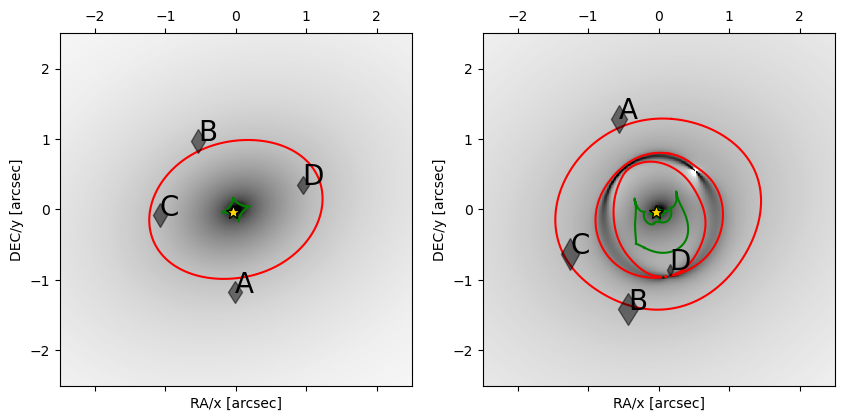

In [5]:
from lenstronomy.Plots import lens_plot
f, axex = plt.subplots(1, 2, figsize=(10, 5), sharex=False, sharey=False)
lens_plot.lens_model_plot(axex[0], lensModel=lensModel, kwargs_lens=kwargs_lens, sourcePos_x=beta_ra, sourcePos_y=beta_dec, point_source=True, with_caustics=True, fast_caustic=True, coord_inverse=False)
lens_plot.lens_model_plot(axex[1], lensModel=lensModel_mp, kwargs_lens=kwargs_lens_mp, sourcePos_x=beta_ra, sourcePos_y=beta_dec, point_source=True, with_caustics=True, fast_caustic=True, coord_inverse=False)
f.show()

Calculated Source Position (RA): 0.01368411489454804
Calculated Source Position (Dec): -0.009273606492634041
Mass density (kappa) at (0.5, 0.5): 0.8503227507763185


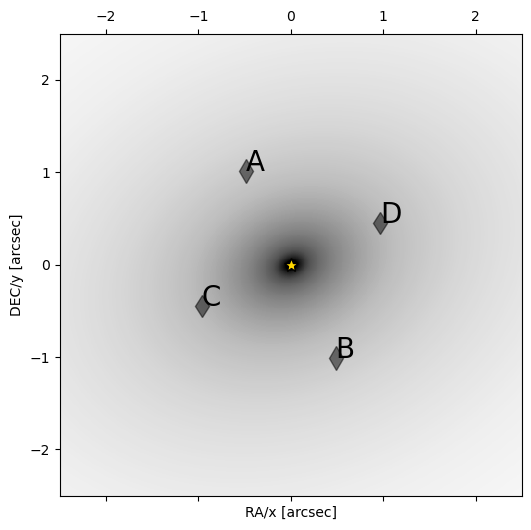

In [6]:
import numpy as np
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Plots import lens_plot
import matplotlib.pyplot as plt

# 1. Setup the lens model (the mass distribution type)
# For example, an Elliptical Power Law (EPL) and External Shear
lens_model_list = ['EPL', 'SHEAR']
lensModel = LensModel(lens_model_list=lens_model_list)

# 2. Define the mass distribution parameters
# These define the 'mass distribution' of your system
kwargs_lens = [
    {'theta_E': 1.1, 'gamma': 2.0, 'e1': 0.1, 'e2': 0.1, 'center_x': 0.0, 'center_y': 0.0},
    {'gamma1': 0.02, 'gamma2': 0.01}
]

# 3. Observed image positions (A, B, C, D coordinates)
# In a real scenario, you would get these from your telescope data
image_ra = np.array([1.21, -1.15, 0.05, -0.08])
image_dec = np.array([0.12, -0.09, 1.18, -1.22])

# 4. FIND THE ORIGINAL SOURCE POSITION (Backward ray-tracing)
# ray_shooting maps image plane coordinates back to the source plane [1]
source_ra, source_dec = lensModel.ray_shooting(image_ra, image_dec, kwargs_lens)

# If the model is correct, all images should map back to the same source position
print(f"Calculated Source Position (RA): {np.mean(source_ra)}")
print(f"Calculated Source Position (Dec): {np.mean(source_dec)}")

# 5. GET THE MASS DISTRIBUTION
# The mass distribution is represented by 'kappa' (convergence) [2]
# We can find the convergence at any specific coordinate
kappa_value = lensModel.kappa(x=0.5, y=0.5, kwargs=kwargs_lens)
print(f"Mass density (kappa) at (0.5, 0.5): {kappa_value}")

# 6. VISUALIZE THE SYSTEM
# This plots the convergence map, critical curves, and caustics [5, 6]
f, ax = plt.subplots(1, 1, figsize=(6, 6))
lens_plot.lens_model_plot(ax, lensModel=lensModel, kwargs_lens=kwargs_lens, 
                          source_pos_x=np.mean(source_ra), 
                          source_pos_y=np.mean(source_dec), 
                          point_source=True)
plt.show()

In [9]:
import numpy as np
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.Solver.solver4point import Solver4Point

# 1. Observed image positions (RA and Dec for images A, B, C, and D)
# These would typically come from your telescope data
x_image = np.array([1.21, -1.15, 0.05, -0.08])
y_image = np.array([0.12, -0.09, 1.18, -1.22])

# 2. Setup the lens model list
lens_model_list = ['EPL', 'SHEAR']
lens_model_instance = LensModel(lens_model_list=lens_model_list)

# 3. Initialize the 4-Point Solver
# The 'PROFILE' type solves for the Einstein radius, center, and ellipticity
# of the first model in the list (the EPL profile) [2].
solver = Solver4Point(lens_model_instance, solver_type='PROFILE')

# 4. Provide initial guesses for the lens parameters
kwargs_init = [
    {'theta_E': 1.0, 'gamma': 2.0, 'e1': 0.0, 'e2': 0.0, 'center_x': 0.0, 'center_y': 0.0},
    {'gamma1': 0.02, 'gamma2': 0.01}
]

# 5. CONSTRAIN THE MODEL
# This method updates the initial kwargs to satisfy the lens equation exactly [4].
kwargs_best_fit, accuracy = solver.constraint_lensmodel(x_image, y_image, kwargs_init)

# 6. PRINT THE CALCULATED VALUES
print("--- Best-fit Mass Parameters (kwargs_lens) ---")
for i, kwargs in enumerate(kwargs_best_fit):
    print(f"Model {i} ({lens_model_list[i]}): {kwargs}")

print(f"\nSolver Accuracy (Euclidean distance in source plane): {accuracy}")

# 7. Find the Original Source Position
# Now that the model is constrained, ray-shooting gives the exact source location [5].
source_ra, source_dec = lens_model_instance.ray_shooting(x_image, y_image, kwargs_best_fit)
print(f"Original Source Position: RA = {np.mean(source_ra):.4f}, Dec = {np.mean(source_dec):.4f}")

--- Best-fit Mass Parameters (kwargs_lens) ---
Model 0 (EPL): {'theta_E': np.float64(1.1953258401838933), 'gamma': 2.0, 'e1': np.float64(0.07862234106589958), 'e2': np.float64(0.019341042832253373), 'center_x': np.float64(0.03517125521391564), 'center_y': np.float64(-0.016480324305018522)}
Model 1 (SHEAR): {'gamma1': 0.02, 'gamma2': 0.01}

Solver Accuracy (Euclidean distance in source plane): 0.00014594438319307426
Original Source Position: RA = 0.0318, Dec = -0.0212
